# Support Vector Machine for Breast Cancer Diagnosis

This script trains, tunes, evaluates, and saves an SVM model for breast cancer diagnosis.
It uses top-2 features for visualization and all features for actual training.

# Load Preprocessed Data

In [98]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score

data_dir = os.path.join('..','data')
models_dir = os.path.join('..','models')

# Load scaled features and labels

In [99]:
X_train_scaled = np.load(os.path.join(data_dir, 'X_train_scaled.npy'))
X_test_scaled = np.load(os.path.join(data_dir, 'X_test_scaled.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

# Train SVM with Hyperparameters tuning

In [100]:
print(f"Samples: {X_train_scaled.shape[0]}")
print(f"Features: {X_train_scaled.shape[1]}")

print(pd.Series(y_train).value_counts(normalize=True))

Samples: 398
Features: 30
0    0.628141
1    0.371859
Name: proportion, dtype: float64


In [101]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svm = SVC(kernel='rbf', class_weight='balanced')

param_grid = {
    'C': [0.01, 0.1, 0.2, 0.3, 1, 10, 100],
    'gamma': [0.01, 0.1, 0.2, 0.3, 1, 'scale']
}

# Focus on recall to avoid False Negatives
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)

grid_search.fit(X=X_train_scaled, y=y_train)

print('Best Cross-validation Accuracy:', {grid_search.best_score_})
print('Best Parameters', grid_search.best_params_)

Best Cross-validation Accuracy: {np.float64(0.9864367816091955)}
Best Parameters {'C': 0.1, 'gamma': 0.2}


## Evaluate the model

In [102]:
best_svm = grid_search.best_estimator_

y_pred = best_svm.predict(X=X_test_scaled)

acc = accuracy_score(y_true=y_test, y_pred=y_pred)
recall_malignant = recall_score(y_true=y_test, y_pred=y_pred)
precision = precision_score(y_true=y_test, y_pred=y_pred)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall (malignant): {recall_malignant:.4f}')

Accuracy: 0.7953
Precision: 0.6495
Recall (malignant): 0.9844


### Confusion Matrix and Classification Report

Evaluate the performance of the model using a confusion matrix and detailed classification metrics.

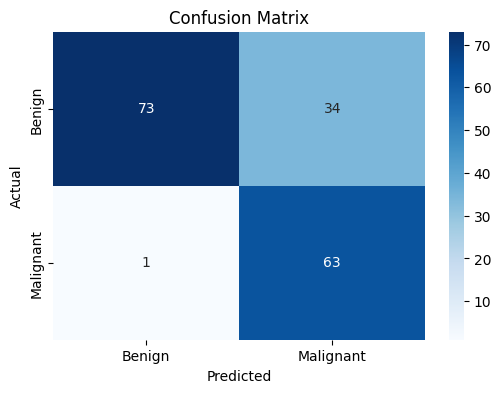


Classification Report:
               precision    recall  f1-score   support

      Benign       0.99      0.68      0.81       107
   Malignant       0.65      0.98      0.78        64

    accuracy                           0.80       171
   macro avg       0.82      0.83      0.79       171
weighted avg       0.86      0.80      0.80       171



In [103]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
cr = classification_report(y_true=y_test, y_pred=y_pred, target_names=['Benign', 'Malignant'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", cr)

### ROC Curve and Compute AUC

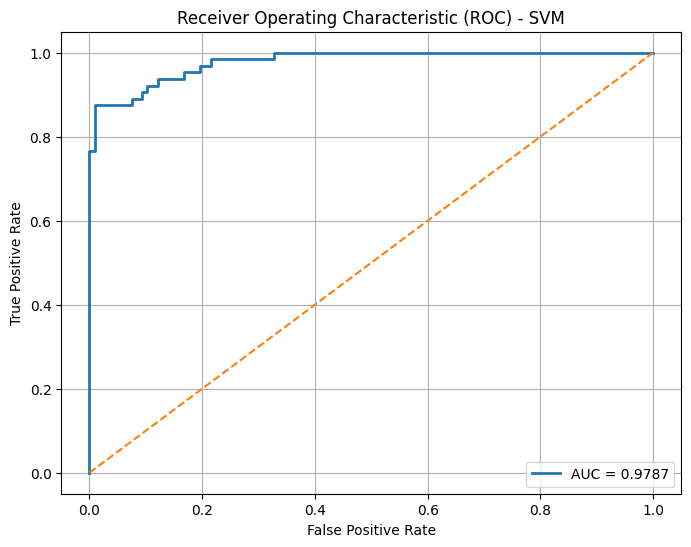

In [104]:
y_scores = best_svm.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_true=y_test, y_score=y_scores)
auc = roc_auc_score(y_true=y_test, y_score=y_scores)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - SVM')
plt.legend()
plt.grid(True)
plt.show()


### Precision-recall curve

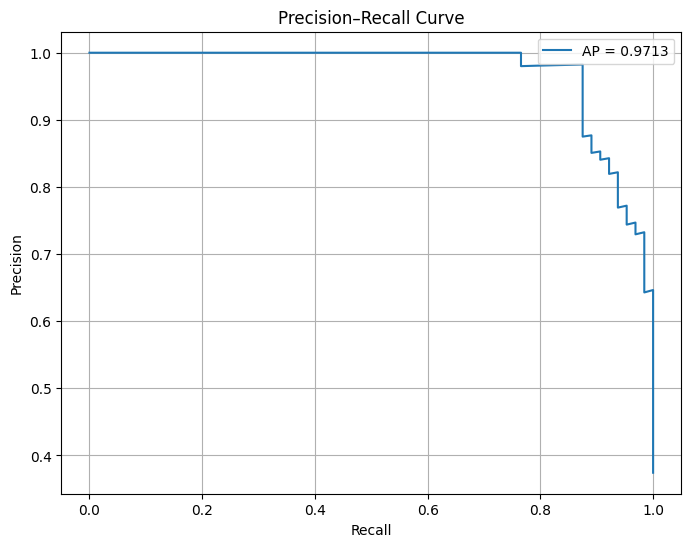

In [105]:
precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP = {avg_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [106]:
from sklearn.metrics import balanced_accuracy_score
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

Balanced Accuracy: 0.8333


### Threshold analysis

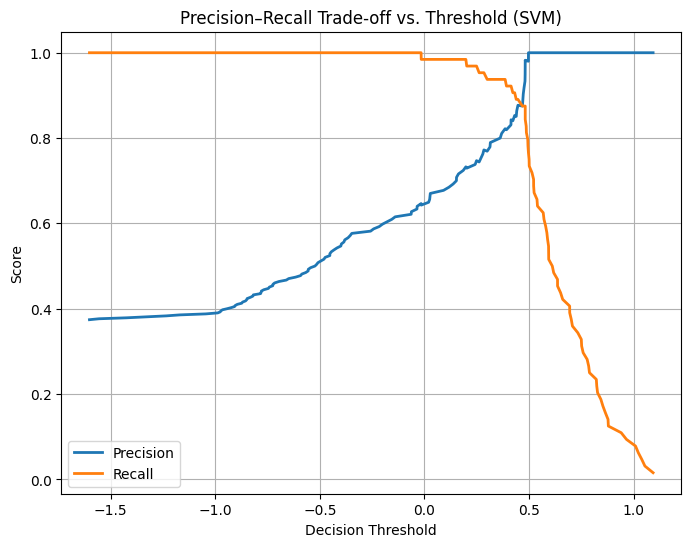

In [107]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], label="Recall", linewidth=2)
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off vs. Threshold (SVM)")
plt.legend()
plt.grid(True)
plt.show()

### Using a custom threshold

Results with custom threshold (-0.05):

Accuracy: 0.7836
Precision: 0.6337
Recall (malignant): 1.0000


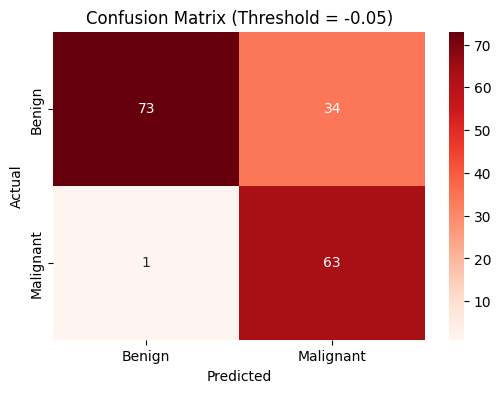


Classification Report (Custom Threshold):
               precision    recall  f1-score   support

      Benign       1.00      0.65      0.79       107
   Malignant       0.63      1.00      0.78        64

    accuracy                           0.78       171
   macro avg       0.82      0.83      0.78       171
weighted avg       0.86      0.78      0.79       171



In [114]:
y_scores = best_svm.decision_function(X_test_scaled)

# A negative threshold will classify more points as 'malignant', increasing recall and decreasing precision
custom_threshold = -0.05

# Create new predictions based on the custom threshold
y_pred_custom = (y_scores > custom_threshold).astype(int)

acc_custom = accuracy_score(y_true=y_test, y_pred=y_pred_custom)
recall_custom = recall_score(y_true=y_test, y_pred=y_pred_custom)
precision_custom = precision_score(y_true=y_test, y_pred=y_pred_custom)

print(f"Results with custom threshold ({custom_threshold}):\n")
print(f'Accuracy: {acc_custom:.4f}')
print(f'Precision: {precision_custom:.4f}')
print(f'Recall (malignant): {recall_custom:.4f}')

# Plot the new confusion matrix for the custom threshold
cm_custom = confusion_matrix(y_true=y_test, y_pred=y_pred_custom)
cr_custom = classification_report(y_true=y_test, y_pred=y_pred_custom, target_names=['Benign', 'Malignant'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {custom_threshold})')
plt.show()

print("\nClassification Report (Custom Threshold):\n", cr_custom)

## Save the Model

In [109]:
import joblib

model_path = os.path.join(models_dir, 'svm_model.joblib')
joblib.dump(best_svm, model_path)

print(f"Model saved to {model_path}")

Model saved to ../models/svm_model.joblib
